### Credit cards are commonly used, but getting one can be tough based on your income and job. To make it easier and increase approval rates, we can use computer models to guess if you'll get approved. In this project, we'll see how different things affect approval and make the computer predictions better.

# Section 1

### Q.1 a)  Why is your proposal important in today’s world? How predicting a good client is worthy for a bank?

#### The idea of guessing who will get a credit card is super important today. Lots of people use credit cards for shopping online, and that's why banks need to be quick and smart about saying yes or no. When banks are good at picking who should get a card, they can avoid losing money when people can't pay their bills. They can also save money by not spending too much time on risky customers. 

#### Banks can use computer programs to figure this out. When they're good at it, they can give cards to people who are not very risky, which means more money for the bank and happier customers.


###  Q.2. How is it going to impact the banking sector? 

#### Using computer predictions to decide who gets a credit card can make banks better in many ways.

#### 1. Happier Customers: When banks use these predictions, they can say yes or no to credit card applications faster and more accurately. This makes customers happier because they get answers quickly. Happy customers are more likely to stay with the bank.

#### 2. Less Risk: These computer programs can also tell banks if someone might not be able to pay their credit card bills. When banks know this, they can give those people cards with lower interest rates. This makes it less likely for people to not pay their bills, which is good for the bank.

#### 3. More Money: When banks are good at predicting who is a good fit for a credit card, they can make more money. They don't lose as much money from people who can't pay, and they save time. With more money, they can offer better deals to customers, which brings in more customers and money.

### Q.3 If any, what is the gap in the knowledge or how your proposed method can be helpful if required in future for any bank in India.

#### If Indian banks need help because they don't know everything about how to approve credit cards or need to make it better, this idea can be a big help. It can make sure they say yes or no to the right people and handle the risk of people not paying better. But for it to work really well, banks need to make sure they have all the right and complete information to use.

# Section 2: Initial Hypothesis (or hypotheses)

###### Hypothesis
Null Hypothesis (H0): There is no significant relationship between an applicant's credit score and credit card approval.

Alternative Hypothesis (H1): There is a significant relationship between an applicant's credit score and credit card approval.

# Section 3: Data analysis approach

In [1]:
#Importing necessarry libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#loading the data set
df1=pd.read_csv("Credit_card.csv")
df2=pd.read_csv("Credit_card_label.csv")
#merging the data set
df=pd.merge(df1,df2,on="Ind_ID")
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


###### From head it is clear  that there is missing value

In [82]:
df.tail()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0
1547,5053790,F,Y,Y,0,225000.0,Working,Higher education,Married,House / apartment,-16601.0,-2859,1,0,0,0,NaN,2,0


###### From tail it is clear  that there is missing value

In [83]:
# To see no.of rows and columns of our dataset purpose to check with the dataset which is given
df.shape

(1548, 19)

In [84]:
 # To get a concise summary of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

###### From above we have 11 continuous variable and  8 categorical variable.

In [85]:
# statistical summary
df.describe()

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,label
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


In [86]:
# To return the column labels of the Dataset.
df.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')

In [87]:
# Let's check for the unique values present in each column
df.nunique()

Ind_ID             1548
GENDER                2
Car_Owner             2
Propert_Owner         2
CHILDREN              6
Annual_income       115
Type_Income           4
EDUCATION             5
Marital_status        5
Housing_type          6
Birthday_count     1270
Employed_days       956
Mobile_phone          1
Work_Phone            2
Phone                 2
EMAIL_ID              2
Type_Occupation      18
Family_Members        7
label                 2
dtype: int64

In [88]:
for col in df.columns:
    unique_values = df[col].unique()
    print(f"'{col}': {unique_values}")

'Ind_ID': [5008827 5009744 5009746 ... 5115992 5118219 5053790]
'GENDER': ['M' 'F' nan]
'Car_Owner': ['Y' 'N']
'Propert_Owner': ['Y' 'N']
'CHILDREN': [ 0  1  2  4  3 14]
'Annual_income': [ 180000.   315000.        nan  450000.    90000.   472500.   270000.
  126000.   202500.   157500.   112500.   540000.   292500.   135000.
   76500.   215100.   225000.    67500.   171000.   103500.    99000.
  391500.    65250.    72900.   360000.   256500.   675000.   247500.
   85500.   121500.   130500.   211500.    81000.    72000.   148500.
  162000.   195750.   585000.   216000.   306000.   108000.    63000.
   45000.   337500.   131400.   117000.   445500.   234000.  1575000.
  144000.    67050.    73350.   193500.   900000.    94500.   198000.
   54000.   166500.   167400.   153000.   423000.   243000.   283500.
  252000.   495000.   612000.    36000.   139500.   133650.   427500.
  261000.   231750.    90900.    45900.   119250.    58500.   328500.
  787500.   594000.   119700.    69372.    

In [89]:
# converting the negative Birthday_Count values to positive
df['Birthday_count']=abs(round((df['Birthday_count']/365),0))
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,37.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,-586,1,1,1,0,NaN,2,1


In [90]:
df['Birthday_count'].unique()

array([51., 37., nan, 61., 50., 52., 24., 46., 35., 33., 49., 44., 43.,
       60., 30., 55., 29., 36., 56., 58., 65., 53., 64., 42., 32., 26.,
       28., 45., 67., 25., 57., 59., 38., 31., 40., 34., 47., 41., 63.,
       54., 48., 62., 27., 39., 66., 23., 68., 22., 21.])

In [91]:
# converting negative values to exprience of the employee
df['Employed_days']=abs(round((df['Employed_days']/365),0))

In [92]:
# replacing the extreme values with zero.
df['Employed_days'].replace(1001.0, 0,inplace=True)

In [93]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,2.0,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1


##### Univariate Analysis

In [94]:
# Extracting numerical columns (int and float) from the  dataset
num_cols = list(df.select_dtypes(['int','float']).columns)

# Printing the list of numerical columns
print("Numerical Columns:")
print(num_cols)

# Extracting categorical columns by finding those columns which are not in the numerical columns
cat_cols = [x for x in df.columns if x not in num_cols]

# Printing the list of categorical columns
print("Categorical Columns:")
print(cat_cols)

Numerical Columns:
['Ind_ID', 'CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'label']
Categorical Columns:
['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


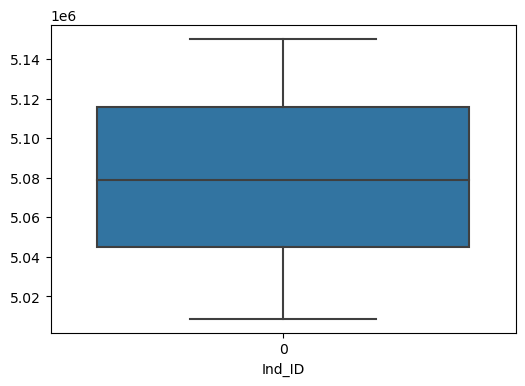

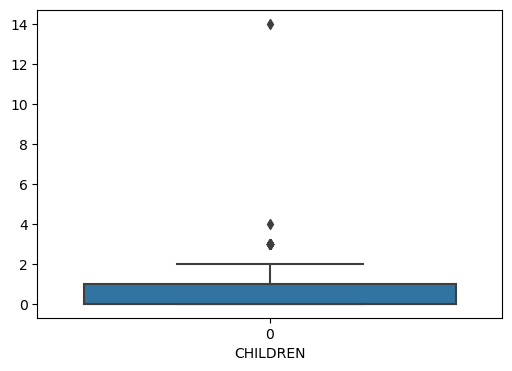

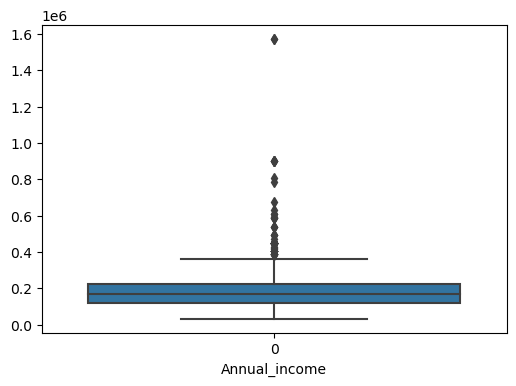

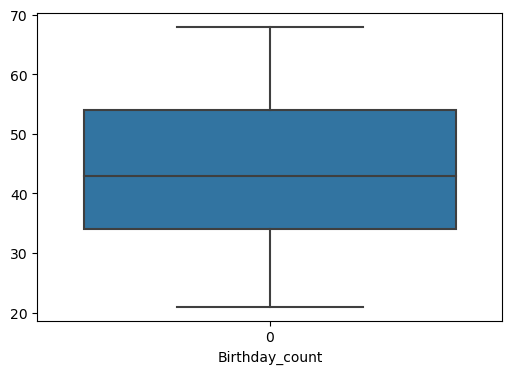

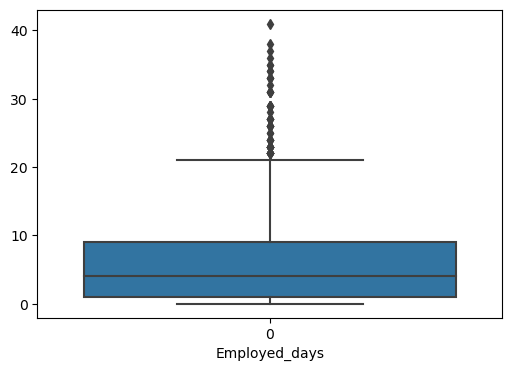

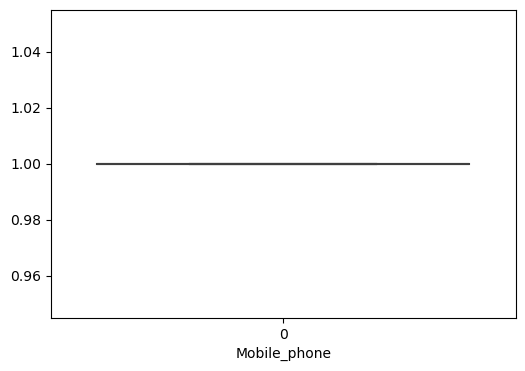

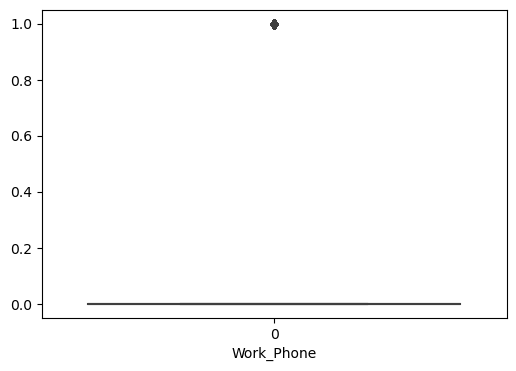

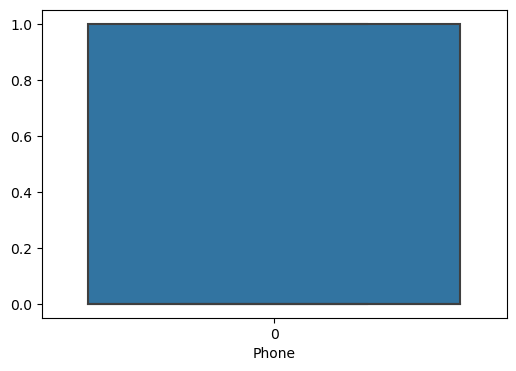

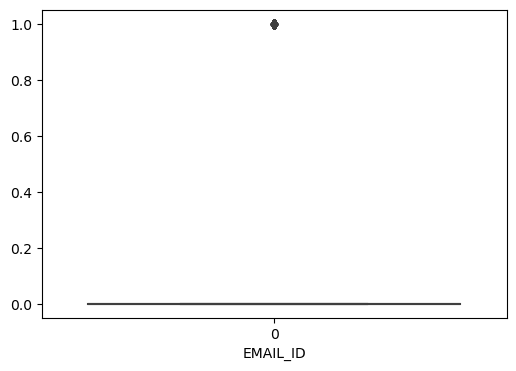

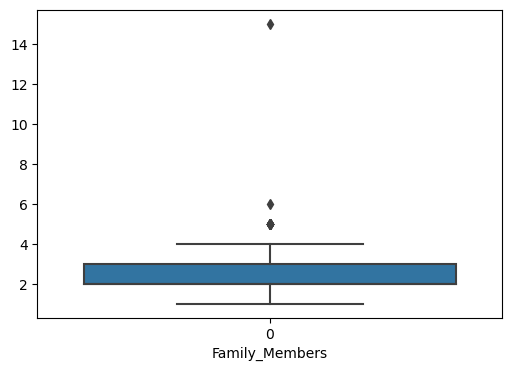

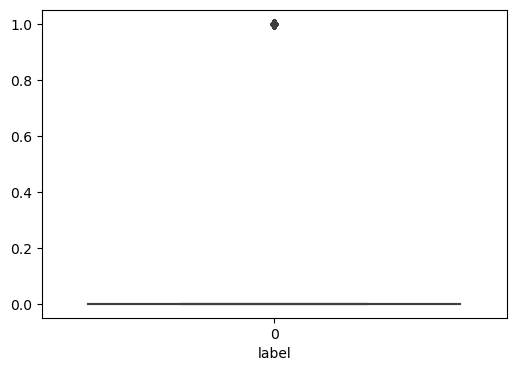

In [95]:
for column in num_cols:
    plt.figure(figsize=(6, 4))  # Create a new figure for each boxplot
    sns.boxplot(df[column])
    plt.xlabel(column)  # Set the x-axis label to the column name
    plt.show()

In [96]:
df[cat_cols].nunique()

GENDER              2
Car_Owner           2
Propert_Owner       2
Type_Income         4
EDUCATION           5
Marital_status      5
Housing_type        6
Type_Occupation    18
dtype: int64

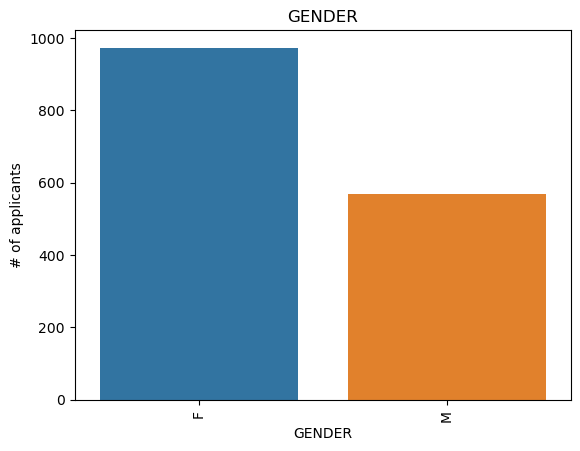

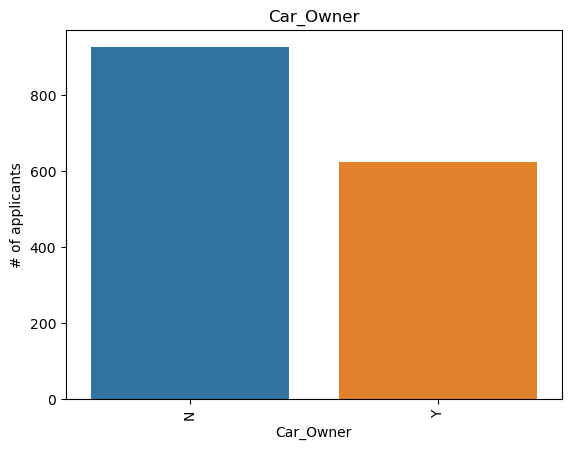

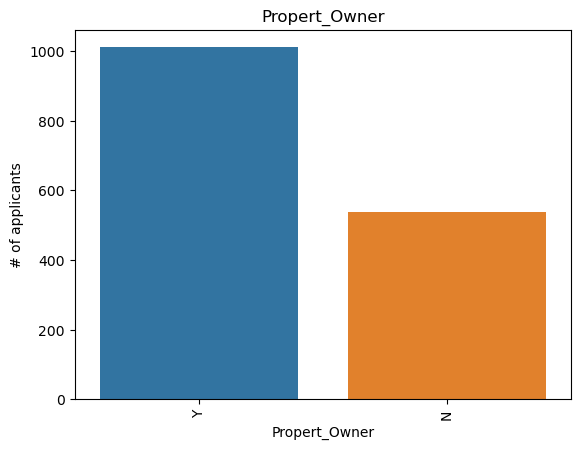

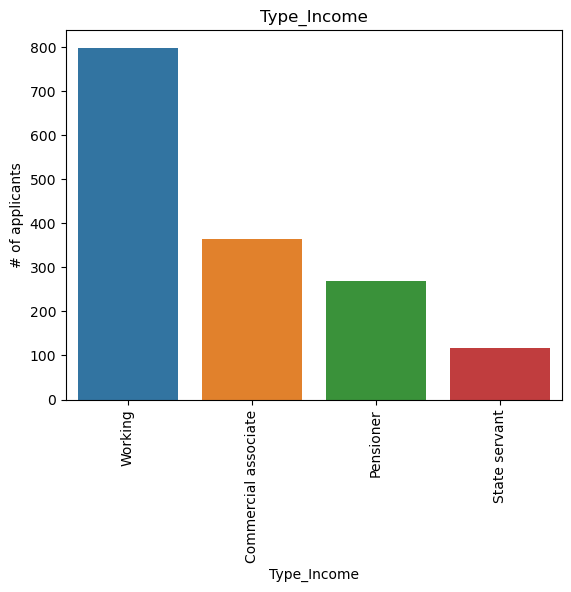

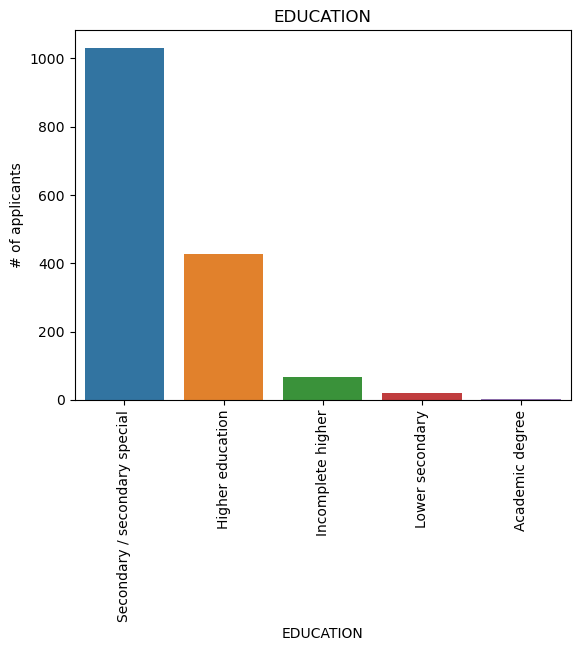

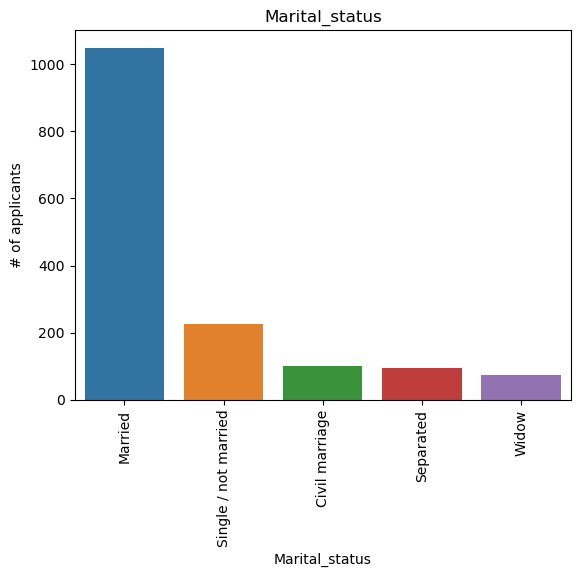

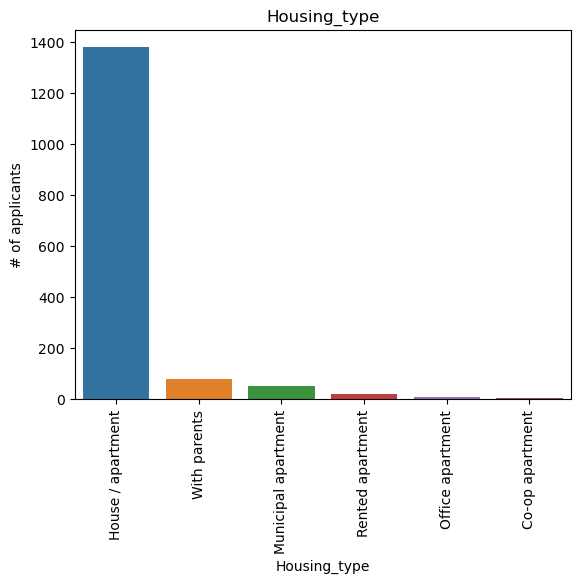

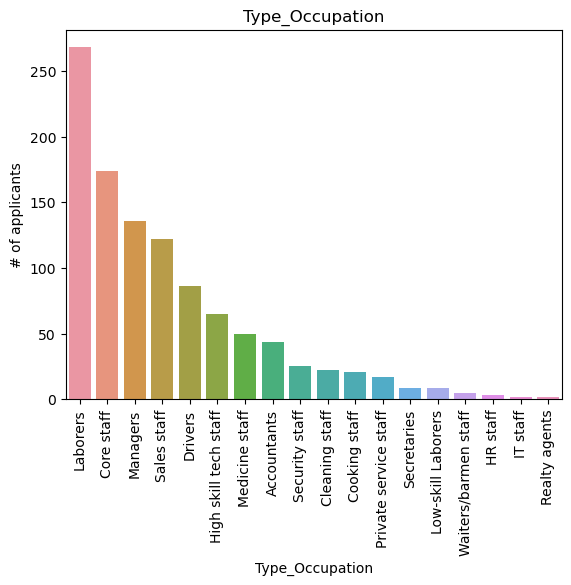

In [97]:
for col in cat_cols:
    cat_num = df[col].value_counts()
    title = col
    cat_num.name = "# of applicants"

    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)

    plt.xlabel(col)
    plt.ylabel("# of applicants")
    plt.title(title)
    plt.show()

### Observation
- Gender - Females are more than males
- Car_owner - More peoples have no car
- Propet_owner - More peoples have their own property
- Type_income - mostly working people are more
- Education - Mostlt people is from secondry education
- housing_type- mostly peopl have house/apartment
- Type_Occupation - mostly people are laborers and lesser than them is ore staff


### Data Cleaning

### Upon analysis, it becomes evident that the "Annual_income" column contains missing values, and these missing values seem to be filled with repeating values from the adjacent rows, either from the row above or the row below. So I am deleting nan value

In [98]:
df=df.dropna(subset=["Annual_income"])

In [99]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,2.0,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1
5,5009753,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,37.0,2.0,1,1,1,0,NaN,2,1


In [100]:
# removing unused columns
df = df.drop(['Ind_ID', 'Mobile_phone','Work_Phone','Phone','EMAIL_ID'], axis=1)
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,2.0,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,NaN,2,1
5,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,37.0,2.0,NaN,2,1


In [101]:
#checking for duplicate records
df.duplicated().sum()  # df.drop_duplicates()

168

In [102]:
df = df.drop_duplicates()

In [103]:

df.shape

(1357, 14)

In [104]:
#missing values
miss_val = df.isnull()
miss_val

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,True,False,True,False,False
5,True,False,False,False,False,False,False,False,False,False,False,True,False,False
7,False,False,False,False,False,False,False,False,False,False,False,True,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [105]:
# Checking for the null values field wise
df.isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Type_Occupation    424
Family_Members       0
label                0
dtype: int64

In [106]:
#percentage of missing value
miss_val.mean()*100

GENDER              0.515844
Car_Owner           0.000000
Propert_Owner       0.000000
CHILDREN            0.000000
Annual_income       0.000000
Type_Income         0.000000
EDUCATION           0.000000
Marital_status      0.000000
Housing_type        0.000000
Birthday_count      1.621223
Employed_days       0.000000
Type_Occupation    31.245394
Family_Members      0.000000
label               0.000000
dtype: float64

##### In the dataset, we have missing or erroneous values in Gender, Annual_income, Birthday_count, Type_occupation

In [107]:
# exploring all rows and columns
pd.options.display.max_columns = None
pd.options.display.max_rows = None
display(df)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,2.0,NaN,2,1
5,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,37.0,2.0,NaN,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,61.0,0.0,NaN,2,1
8,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,50.0,2.0,Core staff,3,1
9,M,Y,Y,1,450000.0,Pensioner,Secondary / secondary special,Married,House / apartment,50.0,2.0,Core staff,3,1
10,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.0,2.0,Core staff,1,1
11,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,52.0,3.0,Cooking staff,2,1
14,M,N,N,1,472500.0,Pensioner,Higher education,Married,With parents,24.0,3.0,NaN,3,1


<Axes: >

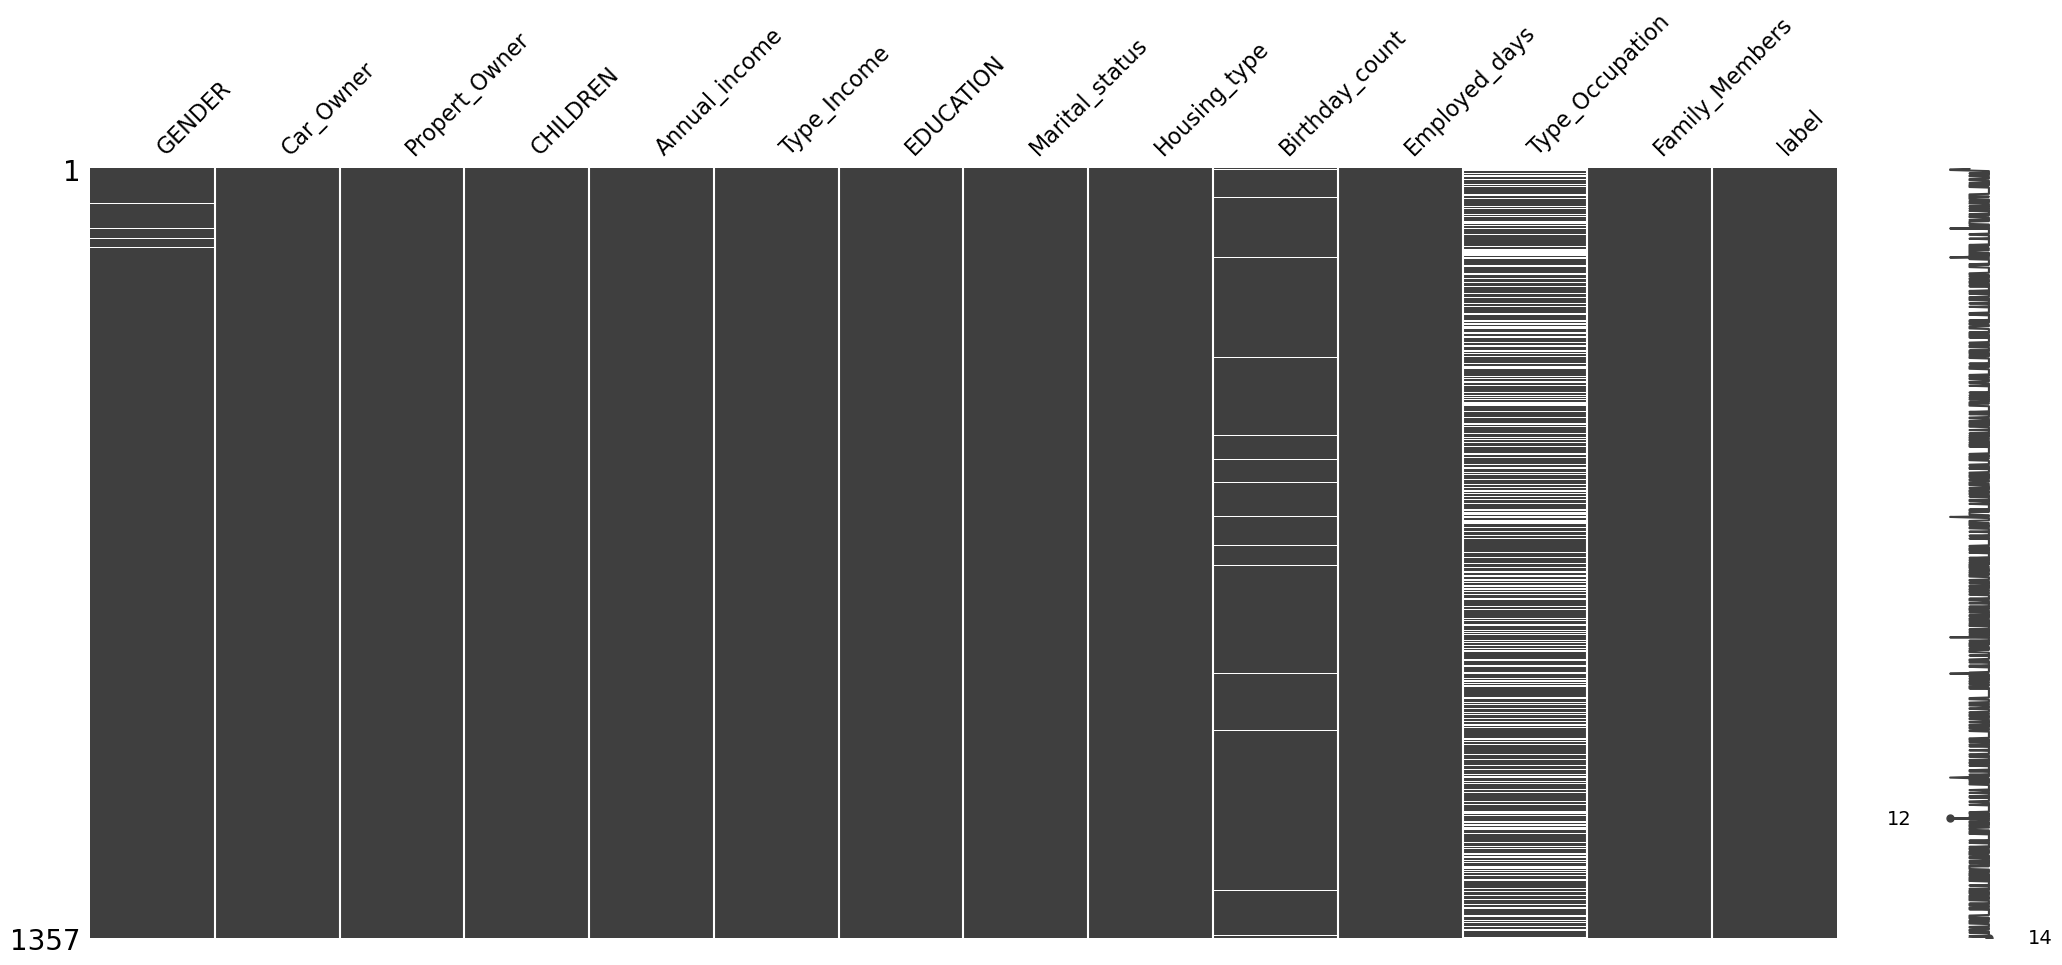

In [108]:
# visualization of missing values
import missingno as msno
msno.matrix(df)

##### To check the correlation between missing no. (heatmap measures nullity correlation)

<Axes: >

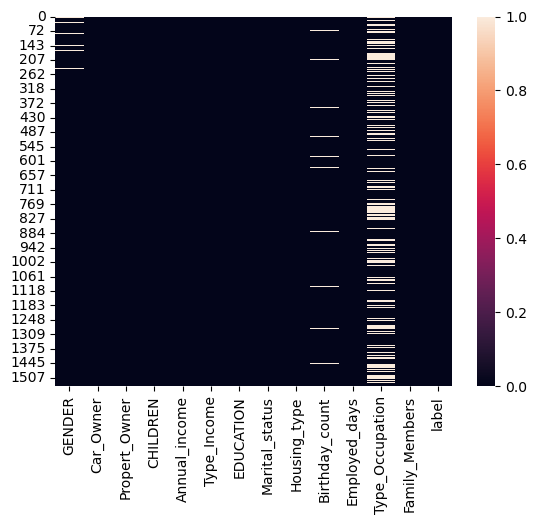

In [109]:
sns.heatmap(df.isnull())

In [110]:
# Deleting the null values in the Gender column
df=df.dropna(subset=["GENDER"])

In [111]:
# replace missing values
df['Type_Occupation'].fillna('other',inplace=True)

In [112]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,other,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,other,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,2.0,other,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,61.0,0.0,other,2,1
8,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,50.0,2.0,Core staff,3,1


### Filling missing value

In [113]:
# Imputation using KNN
from fancyimpute import KNN
knn_imputer = KNN()

# Specify the column with missing values to be imputed
column_to_impute = "Birthday_count"

# Create a deep copy of the data to work with
df_knn = df.copy(deep=True)

# Initialize the KNN imputer
knn_imputer = KNN()

# Perform KNN imputation on the specified column
df_knn[column_to_impute] = knn_imputer.fit_transform(df_knn[[column_to_impute]])


Imputing row 1/1350 with 0 missing, elapsed time: 0.637
Imputing row 101/1350 with 0 missing, elapsed time: 0.638
Imputing row 201/1350 with 0 missing, elapsed time: 0.639
Imputing row 301/1350 with 0 missing, elapsed time: 0.639
Imputing row 401/1350 with 0 missing, elapsed time: 0.640
Imputing row 501/1350 with 0 missing, elapsed time: 0.641
Imputing row 601/1350 with 0 missing, elapsed time: 0.642
Imputing row 701/1350 with 0 missing, elapsed time: 0.643
Imputing row 801/1350 with 0 missing, elapsed time: 0.644
Imputing row 901/1350 with 0 missing, elapsed time: 0.644
Imputing row 1001/1350 with 0 missing, elapsed time: 0.645
Imputing row 1101/1350 with 0 missing, elapsed time: 0.646
Imputing row 1201/1350 with 0 missing, elapsed time: 0.647
Imputing row 1301/1350 with 0 missing, elapsed time: 0.648
[KNN] Warning: 22/1350 still missing after imputation, replacing with 0


In [114]:
# Imputation using MICE
from fancyimpute import IterativeImputer

# Specify the column to impute
column_to_impute = "Birthday_count"

# Create an instance of the MICE imputer
MICE_imputer = IterativeImputer()

# Create a deep copy of the DataFrame
df_MICE = df.copy(deep=True)

# Perform MICE imputation on the specified column
df_MICE[[column_to_impute]] = MICE_imputer.fit_transform(df_MICE[[column_to_impute]])

In [115]:
# Mean Imputation
from sklearn.impute import SimpleImputer

column_to_impute = "Birthday_count"
df_mean = df.copy(deep=True)  # Creating another copy of the dataset; deep=True ensures it will not affect the original dataset
mean_imputer = SimpleImputer(strategy='mean')
df_mean[column_to_impute] = mean_imputer.fit_transform(df_mean[[column_to_impute]])


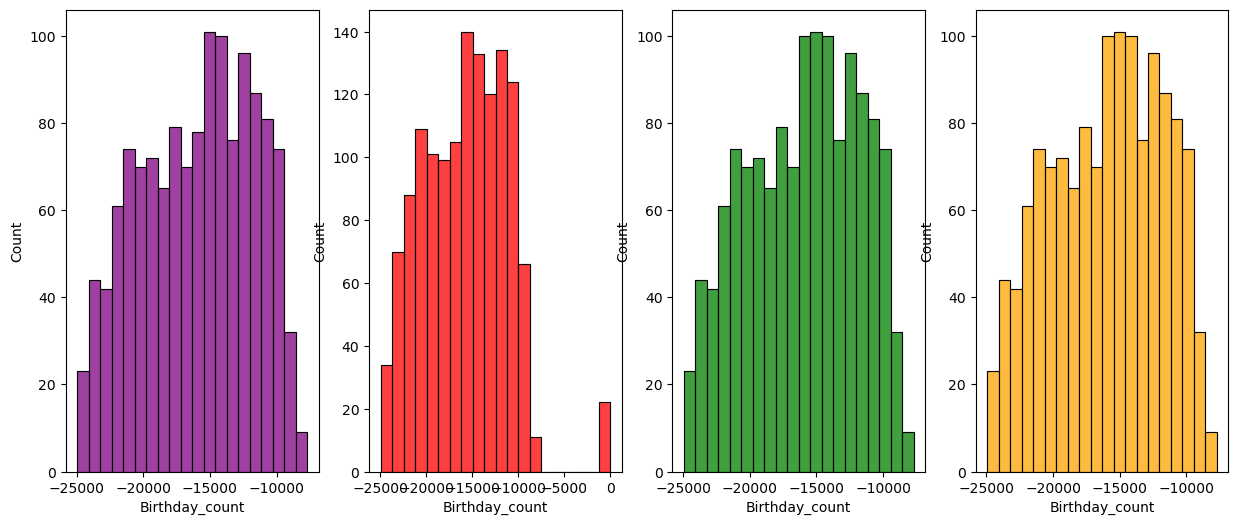

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(15, 6))  # Create 1 row and 3 columns of subplots

# Plot the first histogram on the first subplot
sns.histplot(df['Birthday_count'], bins=20, color="purple", ax=axes[0])

# Plot the second histogram on the second subplot
sns.histplot(df_knn['Birthday_count'], color="red", bins=20, ax=axes[1])

# Plot the second histogram on the second subplot
sns.histplot(df_MICE['Birthday_count'], color="green", bins=20, ax=axes[2])

# Plot the second histogram on the second subplot
sns.histplot(df_mean['Birthday_count'], color="orange", bins=20, ax=axes[3])

plt.show()  # Show the subplot

In [116]:
df_knn.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,other,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,other,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,0.0,2.0,other,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,61.0,0.0,other,2,1
8,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,50.0,2.0,Core staff,3,1


##### From above exploration it seems that from MICE and KNN,  KNN performed well. Hence, I will go ahead with KNN imputation

### Checking Outliers

Numerical Columns:
['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'label']


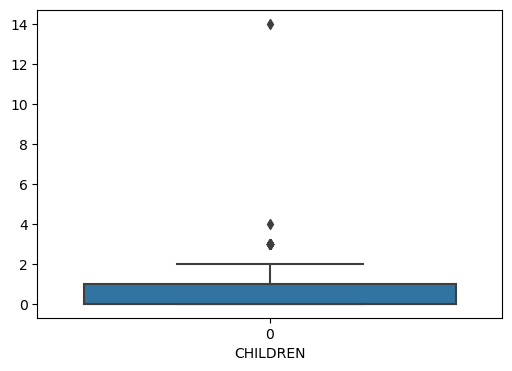

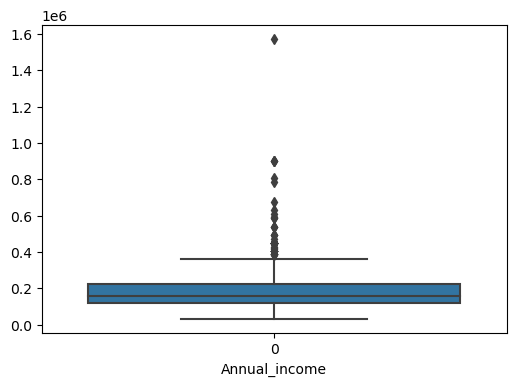

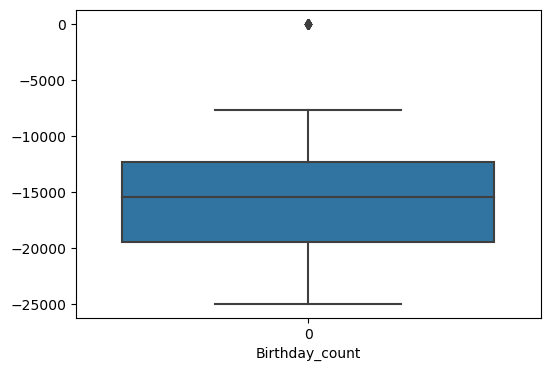

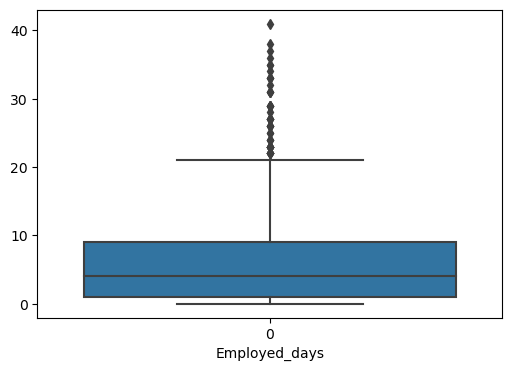

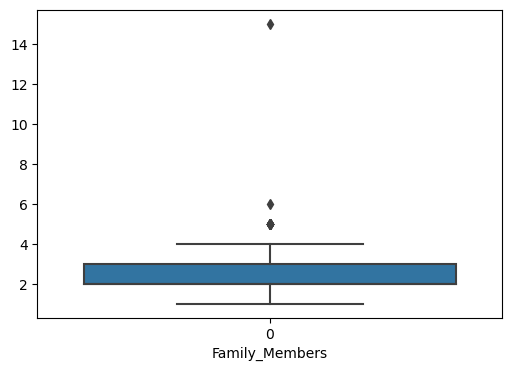

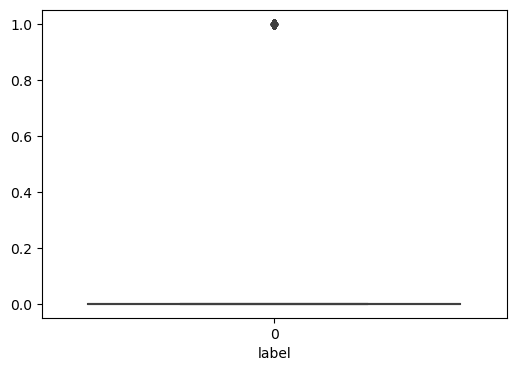

In [31]:
numm_cols = list(df_knn.select_dtypes(['int','float']).columns)

# Printing the list of numerical columns
print("Numerical Columns:")
print(numm_cols)

for i in numm_cols:
    plt.figure(figsize=(6, 4))  # Create a new figure for each boxplot
    sns.boxplot(df_knn[i])
    plt.xlabel(i)  # Set the x-axis label to the column name
    plt.show()

### Bivariate Analysis

In [45]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1357 entries, 0 to 1547
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENDER           1350 non-null   object 
 1   Car_Owner        1357 non-null   object 
 2   Propert_Owner    1357 non-null   object 
 3   CHILDREN         1357 non-null   int64  
 4   Annual_income    1357 non-null   float64
 5   Type_Income      1357 non-null   object 
 6   EDUCATION        1357 non-null   object 
 7   Marital_status   1357 non-null   object 
 8   Housing_type     1357 non-null   object 
 9   Birthday_count   1357 non-null   float64
 10  Employed_days    1357 non-null   float64
 11  Type_Occupation  933 non-null    object 
 12  Family_Members   1357 non-null   int64  
 13  label            1357 non-null   int64  
dtypes: float64(3), int64(3), object(8)
memory usage: 191.3+ KB


### Categorical-Numerical

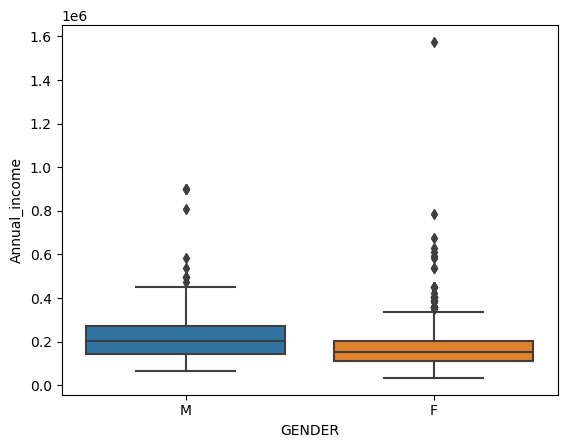

In [32]:
sns.boxplot(x ='GENDER',y ="Annual_income",data=df_knn)
plt.show()

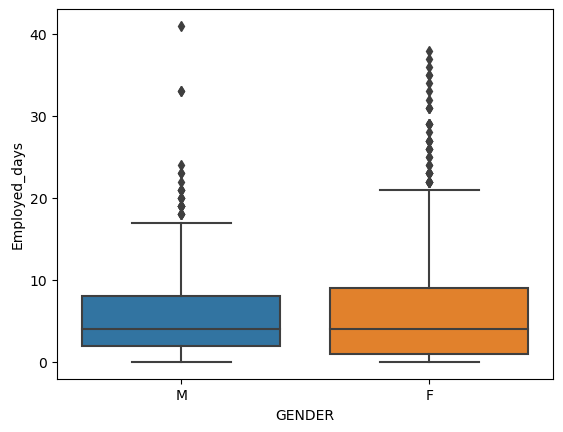

In [33]:
sns.boxplot(x ='GENDER',y ="Employed_days",data=df_knn)
plt.show()

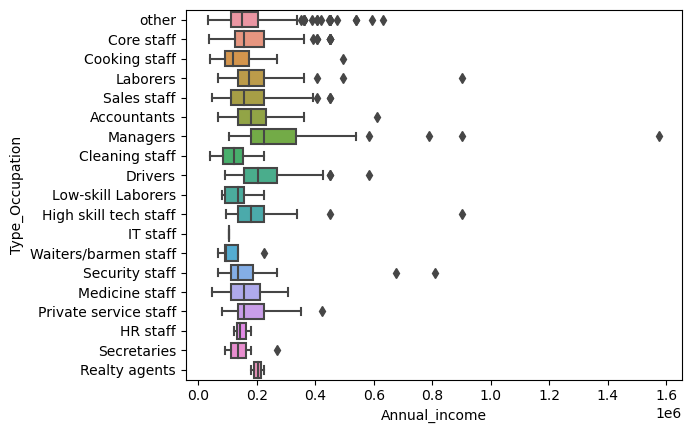

In [34]:
sns.boxplot(x ='Annual_income',y ="Type_Occupation",data=df_knn)
plt.show()

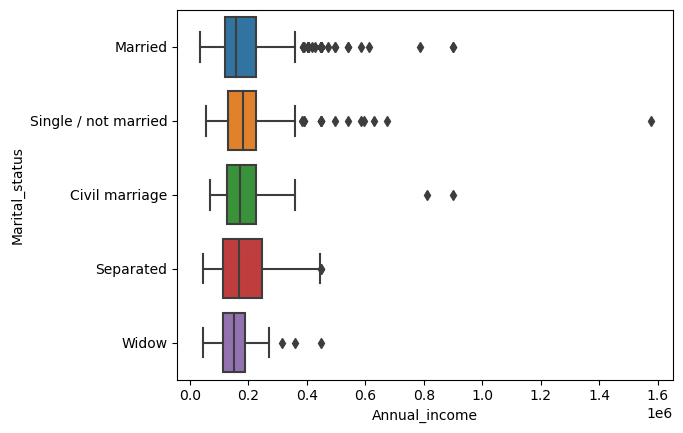

In [42]:
sns.boxplot(x ='Annual_income',y ="Marital_status",data=df_knn)
plt.show()

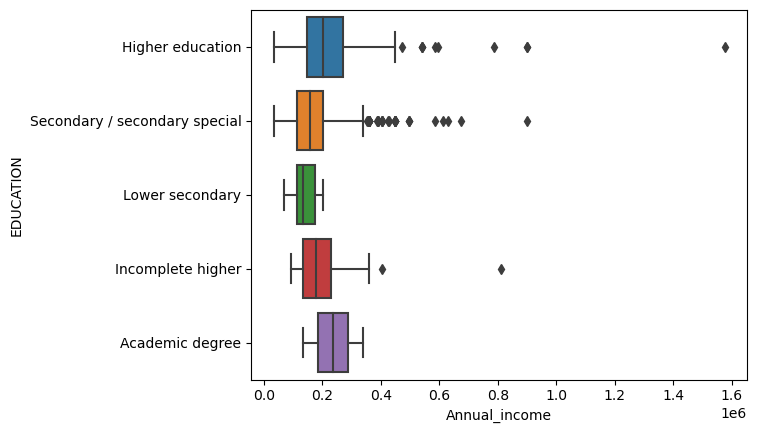

In [43]:
sns.boxplot(x ='Annual_income',y ="EDUCATION",data=df_knn)
plt.show()

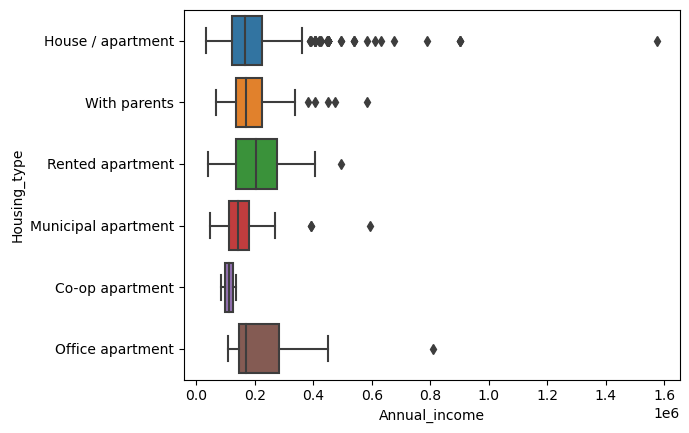

In [44]:
sns.boxplot(x ='Annual_income',y ="Housing_type",data=df_knn)
plt.show()

# SQL

In [117]:
import duckdb
conn = duckdb.connect()
conn.register('dff_knn',df_knn)

In [118]:
conn.execute('select * from df_knn limit 5').fetchdf()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,51.0,0.0,other,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,37.0,2.0,other,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,0.0,2.0,other,2,1
3,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,61.0,0.0,other,2,1
4,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,50.0,2.0,Core staff,3,1


### 1) Group the customers based on their income type and find the average of their annual income.

In [125]:
conn.execute('SELECT Type_Income, AVG(Annual_income) as Average_Annual_income FROM df_knn GROUP BY Type_Income LIMIT 5').fetchdf()

,Type_Income,Average_Annual_income
0,Pensioner,154237.770386
1,Working,181022.301724
2,State servant,205740.000000
3,Commercial associate,226592.523364


### 2) Find the female owners of cars and property.

In [137]:
conn.execute('SELECT Car_Owner, Propert_Owner FROM df_knn WHERE GENDER = \'F\'limit 5' ).fetchdf()

,Car_Owner,Propert_Owner
0,Y,N
1,Y,N
2,N,N
3,Y,Y
4,N,Y


### 3) Find the male customers who are staying with their families.

In [138]:
conn.execute('SELECT count(Family_Members) FROM df_knn WHERE GENDER = \'M\' and Family_Members>1 limit 5' ).fetchdf()

,count(Family_Members)
0,414


###  4) Please list the top five people having the highest income.

In [139]:
conn.execute('SELECT * FROM df_knn ORDER BY Annual_income DESC LIMIT 5').fetchdf()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,F,Y,Y,1,1575000.0,Commercial associate,Higher education,Single / not married,House / apartment,28.0,7.0,Managers,2,0
1,M,N,Y,1,900000.0,Working,Secondary / secondary special,Married,House / apartment,42.0,12.0,Laborers,3,0
2,M,Y,Y,2,900000.0,Commercial associate,Higher education,Married,House / apartment,27.0,3.0,Managers,4,0
3,M,Y,Y,1,900000.0,Commercial associate,Higher education,Civil marriage,House / apartment,46.0,7.0,High skill tech staff,3,0
4,M,Y,Y,1,810000.0,Commercial associate,Incomplete higher,Civil marriage,Office apartment,49.0,9.0,Security staff,3,0


### 5) How many married people are having bad credit?

In [142]:
conn.execute("SELECT COUNT(*) as BadCreditCount FROM df_knn WHERE Marital_status = 'Married' AND label = 0").fetchdf()


,BadCreditCount
0,839


### 6) What is the highest education level and what is the total count?

In [144]:
conn.execute("SELECT EDUCATION, COUNT(*) as EducationCount FROM df_knn GROUP BY EDUCATION ORDER BY EducationCount DESC LIMIT 1").fetchdf()

,EDUCATION,EducationCount
0,Secondary / secondary special,908


### 7) Between married males and females, who is having more bad credit? 

In [147]:
conn.execute('SELECT Marital_status, GENDER, COUNT(*) as BadCreditCount FROM df_knn WHERE Marital_status = \'Married\' AND label = 0 GROUP BY Marital_status, GENDER').fetchdf()

,Marital_status,GENDER,BadCreditCount
0,Married,F,509
1,Married,M,330


### Feature Engineering - Encoding

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1356 entries, 0 to 1547
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENDER           1356 non-null   object 
 1   Car_Owner        1356 non-null   object 
 2   Propert_Owner    1356 non-null   object 
 3   CHILDREN         1356 non-null   int64  
 4   Annual_income    1356 non-null   float64
 5   Type_Income      1356 non-null   object 
 6   EDUCATION        1356 non-null   object 
 7   Marital_status   1356 non-null   object 
 8   Housing_type     1356 non-null   object 
 9   Birthday_count   1334 non-null   float64
 10  Employed_days    1356 non-null   float64
 11  Type_Occupation  1356 non-null   object 
 12  Family_Members   1356 non-null   int64  
 13  label            1356 non-null   int64  
dtypes: float64(3), int64(3), object(8)
memory usage: 191.2+ KB


In [36]:
# Ordinal encoding for Type_Income","EDUCATION", "Marital_status","Housing_type","Type_Occupation
# we can also use regular expression too

from sklearn.preprocessing import OrdinalEncoder

columns_to_encode = ["Type_Income", "EDUCATION", "Marital_status", "Housing_type", "Type_Occupation"]
encoder = OrdinalEncoder()
df_knn[columns_to_encode] = encoder.fit_transform(df_knn[columns_to_encode])


In [37]:
#Converting categories into numbers
df_knn['GENDER'] = df_knn['GENDER'].map({'M': 0, 'F': 1})
df_knn['Car_Owner'] = df_knn['Car_Owner'].map({'N' : 0 , 'Y' : 1})
df_knn['Propert_Owner'] = df_knn['Propert_Owner'].map({'N' : 0, 'Y': 1})
df_knn.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Type_Occupation,Family_Members,label
0,0,1,1,0,180000.0,1.0,1.0,1.0,1.0,-18772.0,0.0,18.0,2,1
1,1,1,0,0,315000.0,0.0,1.0,1.0,1.0,-13557.0,2.0,18.0,2,1
2,1,1,0,0,315000.0,0.0,1.0,1.0,1.0,0.0,2.0,18.0,2,1
7,1,0,0,0,180000.0,1.0,4.0,1.0,1.0,-22134.0,0.0,18.0,2,1
8,0,1,1,1,450000.0,0.0,4.0,1.0,1.0,-18173.0,2.0,3.0,3,1


### Model Building - Feature Scaling

In [38]:
# feature scaling
from sklearn.model_selection import train_test_split
# spliting the data 
x = df2.iloc[:,0:-1]
y = df2.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=40)

In [39]:
# count the number rows and columns for x_test
x_test.shape

(465, 1)

In [40]:
# count the number rows and columns for x_train
x_train.shape

(1083, 1)

In [41]:
# count the number rows for y_test
y_test.shape

(465,)

In [42]:
# count the number rows for y_train
y_train.shape

(1083,)

## Scaling

In [43]:
# importing the MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
rescale_x_train = scaler.fit_transform(x_train)
rescale_x_test = scaler.fit_transform(x_test)
print(rescale_x_train.shape)
print(rescale_x_test.shape)

(1083, 1)
(465, 1)


### Applying ML algorithm to the pre-processed columns and find out, which of these algorithms is best suitable.

### Machine Learning Classifiers
###### Now we have our dataset ready for building a machine learning-based classifier. There are several classification models that can be used for this task. In this analysis, we will build five different types of classification models namely 
- Logistic Regression, 
- Decision Tree, 
- Random Forest, 
- XGBoost  
###### These are the most popular models used for solving classification problems. All these models can be conveniently implemented using python’s scikit-learn package except for the XGBoost model, which is implemented using the XGBoost package.

### 1) Logistic Regression:

In [44]:
# importing the LogisticRegression
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=0)
logreg.fit(rescale_x_train, y_train)

LogisticRegression(random_state=0)

In [45]:
#Importing scikit-learn metrics module for accuracy calculation
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = logreg.predict(rescale_x_test)
print("logistic regression training set:",logreg.score(x_train, y_train))
print("logistic regression testing set:",logreg.score(x_test, y_test))
print("Accuracy of logistic regression classifier: ", accuracy_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

logistic regression training set: 0.11265004616805172
logistic regression testing set: 0.11397849462365592
Accuracy of logistic regression classifier:  0.886021505376344
[[412   0]
 [ 53   0]]


### cross validation

In [46]:
# cross validation
from sklearn.model_selection import ShuffleSplit
model= LogisticRegression()
ssplit=ShuffleSplit(n_splits=10,test_size=0.20)
from sklearn.model_selection import cross_val_score
results=cross_val_score(model,x,y,cv=ssplit)
print(results)
print(np.mean(results))

[0.87741935 0.89032258 0.89032258 0.88387097 0.90322581 0.9
 0.86129032 0.88709677 0.88064516 0.87096774]
0.8845161290322581


In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ShuffleSplit

# Create logistic regression model
model = LogisticRegression()

# Specify hyperparameters and their possible values
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear', 'saga']}

# Create ShuffleSplit cross-validation object
ssplit = ShuffleSplit(n_splits=10, test_size=0.20)

# Create GridSearchCV object
grid_search = GridSearchCV(model, param_grid, cv=ssplit)

# Fit the model with hyperparameter tuning
grid_search.fit(x, y)

# Print the best hyperparameters
print("Best Hyperparameters: ", grid_search.best_params_)

# Print the mean cross-validated score of the best estimator
print("Best Mean Cross-validated Score: ", grid_search.best_score_)


Best Hyperparameters:  {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best Mean Cross-validated Score:  0.8829032258064518


###  2) Decision Tree

In [48]:
# decision tree classification  without rescaled
from sklearn.tree import DecisionTreeClassifier
classification = DecisionTreeClassifier()
classification = classification.fit(x_train,y_train)
y_pred = classification.predict(x_test)
print("decision tree training set:",classification.score(x_train, y_train))
print("decision tree testing set:",classification.score(x_test, y_test))
print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))

decision tree training set: 1.0
decision tree testing set: 0.8666666666666667
Accuracy: 0.8666666666666667
[[377  35]
 [ 27  26]]


### cross validation

In [49]:
# cross validation
from sklearn.model_selection import ShuffleSplit
model= DecisionTreeClassifier()
ssplit=ShuffleSplit(n_splits=10,test_size=0.20)
from sklearn.model_selection import cross_val_score
results=cross_val_score(model,x,y,cv=ssplit)
print(results)
print(np.mean(results))

[0.86774194 0.87419355 0.89677419 0.88064516 0.83870968 0.8516129
 0.88709677 0.89032258 0.9        0.89354839]
0.8780645161290324


### 3) XG boost

In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
xg=XGBClassifier()
xg=xg.fit(x_train,y_train)
y_pred=xg.predict(x_test)
print("xg training set:",xg.score(x_train, y_train))
print("xg testing set:",xg.score(x_test, y_test))
print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))

xg training set: 0.9058171745152355
xg testing set: 0.8709677419354839
Accuracy: 0.8709677419354839
[[403   9]
 [ 51   2]]


### cross validation

In [51]:
# cross validation
from sklearn.model_selection import ShuffleSplit
model=XGBClassifier()
ssplit=ShuffleSplit(n_splits=10,test_size=0.20)
from sklearn.model_selection import cross_val_score
results=cross_val_score(model,x,y,cv=ssplit)
print(results)
print(np.mean(results))

[0.87741935 0.87741935 0.87419355 0.86451613 0.87096774 0.88709677
 0.89032258 0.88709677 0.86129032 0.91290323]
0.8803225806451612


###  4) Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
print("rf training set:",rf.score(x_train, y_train))
print("rf testing set:",rf.score(x_test, y_test))
print("Random Forest classifier has accuracy of: ", rf.score(x_test, y_test))
# Evaluate the confusion_matrix
print(confusion_matrix(y_test, y_pred))

rf training set: 1.0
rf testing set: 0.8666666666666667
Random Forest classifier has accuracy of:  0.8666666666666667
[[377  35]
 [ 27  26]]


### cross validation

In [53]:
# cross validation
from sklearn.model_selection import ShuffleSplit
model=RandomForestClassifier()
ssplit=ShuffleSplit(n_splits=10,test_size=0.20)
from sklearn.model_selection import cross_val_score
results=cross_val_score(model,x,y,cv=ssplit)
print(results)
print(np.mean(results))

[0.87419355 0.85806452 0.85806452 0.88709677 0.9        0.87419355
 0.86774194 0.87419355 0.85806452 0.87419355]
0.8725806451612904


### Conclusion

In [110]:
| Model                | Test Accuracy | Train Accuracy | Cross validated accuracy|
|----------------------|---------------|----------------|-------------------------|
| Logistic Regression  |      11%      |      11%       |          88%            |
| Decision Tree        |     100%      |      86%       |          86%            |
| XG Boosting          |      90%      |      87%       |          87%            |
| Random Forest        |      100%     |      86%       |          86%            |
---------------------- |---------------|----------------|--------------------------


###### I have tried four different classification models for credit card approval prediction task. The train and test accuracy of the models is summarized in the Figure above. We have obtained the best test data accuracy (87%) from the XG Boosting classifier. The small difference in train and test accuracy scores indicates the absence of overfitting and underfitting.

###### Based on the provided information, XGBoost seems to be the most promising model among the ones listed. It achieves a good balance between training and testing set accuracy and has a higher overall accuracy compared to logistic regression and decision tree models.

### Analysis:

###### Logistic Rgression
- Test Accuracy: 11%
- Train Accuracy: 11%
- Cross-Validated Accuracy: 88%
- Comments: The low test and train accuracies suggest that the model might not be performing well on the given data. However, the cross-validated accuracy is considerably higher, indicating better performance across different data splits.

###### Decision Tree:
- Test Accuracy: 100%
- Train Accuracy: 86%
- Cross-Validated Accuracy: 86%
- Comments: A test accuracy of 100% might indicate overfitting on the training data. The model is achieving lower cross-         validated accuracy, which suggests it may not generalize well to different data splits.

###### XG Boosting:
- Test Accuracy: 90%
- Train Accuracy: 87%
- Cross-Validated Accuracy: 87%
- Comments: This model shows a good balance between test and train accuracies, and the cross-validated accuracy is consistent.   It seems to generalize well to new data.

###### Random Forest:
- Test Accuracy: 100%
- Train Accuracy: 86%
- Cross-Validated Accuracy: 86%
- Comments: Similar to the decision tree, a test accuracy of 100% suggests potential overfitting. The cross-validated accuracy   is in line with the decision tree, indicating similar generalization performance.